In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# scale data
def scale(X, X_min, X_max):
    return (X - X_min)/(X_max-X_min)

NUM_CLASSES = 3

epochs = 1000
batch_size = 32
num_neurons = 10
seed = 10

np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
histories = {}

In [4]:
#read train data
train_input = np.genfromtxt('ctg_data_cleaned.csv', delimiter= ',')
x, y = train_input[1:, :21], train_input[1:,-1].astype(int)
x = scale(x, np.min(x, axis=0), np.max(x, axis=0))
y = y-1

In [15]:
# create the model
model = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(units=NUM_CLASSES, activation='softmax')
])


In [16]:
opt = SGD(lr=0.01)

In [17]:
model.compile(optimizer=opt,
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [18]:
# train the model
histories["model"] =model.fit(x, y,
                            validation_split = 0.3,
                            epochs=epochs,
                            verbose = 0,
                            batch_size=batch_size)

print('Training complete')

Training complete


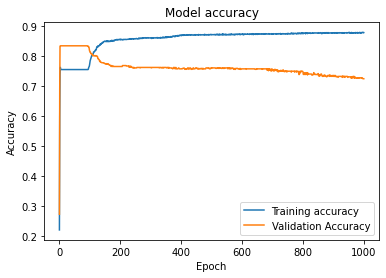

In [19]:
# plot learning curves
plt.plot(histories['model'].history['accuracy'])
plt.plot(histories['model'].history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training accuracy', 'Validation Accuracy'], loc='lower right')
plt.show()